# Telco Customer Churn Prediction

**Position**: Junior Data Scientist

**Author**: Patryk Małysa


This project explores customer churn behavior in a telecom company and builds machine learning models to predict whether a customer is likely to leave.

The notebook includes:
- data understanding and cleaning,
- exploratory data analysis,
- preprocessing and model training,
- model comparison and interpretation.

## Imports

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)


## Data Understanding and Cleaning

In this section, we will conduct an exploratory data analysis (EDA) to understand the dataset's structure and content. During the data loading process, we checked data type in each column, dropped `customerID` column, checked number of missing values in each column. After that we changed `TotalCharges` data type from text to numerical, and again checked number of missing values.

In [58]:
df = pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
print("Dataset shape:", df.shape)
print()
df.info()

Dataset shape: (7043, 21)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non

In [60]:
df = df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [89]:
print("Missing values before converting TotalCharges to numeric:")
df.isnull().sum()

Missing values before converting TotalCharges to numeric:


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [62]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [63]:
print("Missing values after converting TotalCharges to numeric:")
df.isnull().sum()

Missing values after converting TotalCharges to numeric:


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [64]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [65]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 22


22 duplicate rows were detected. Since the duplicates may represent valid customers with identical service configurations rather than data entry errors, they were retained.

In [66]:
print("Churn counts:")
display(df["Churn"].value_counts())

print("Churn proportions:")
display(df["Churn"].value_counts(normalize=True))

Churn counts:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn proportions:


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

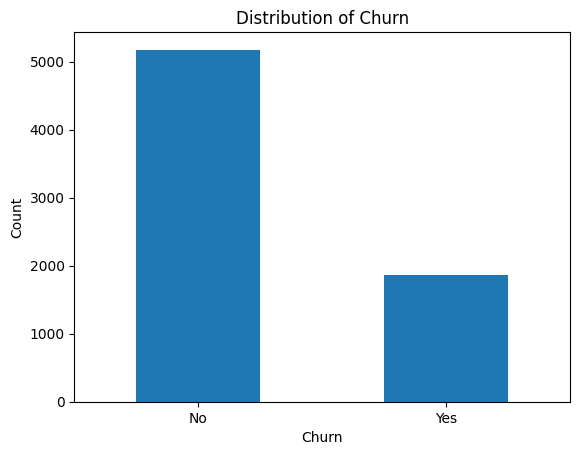

In [67]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80


### Data cleaning summary

The following preprocessing steps were applied before the exploratory analysis:
- removed `customerID`, as it does not provide predictive value,
- converted `TotalCharges` to numeric format,
- filled missing values in `TotalCharges` with the median,
- checked for duplicate rows,
- reviewed the target class distribution.

## Exploratory Data Analysis

### Categorical feature analysis

In [69]:
categorical_cols = df.select_dtypes(include=["str"]).columns
numerical_cols = df.select_dtypes(exclude=["str"]).columns

print("Categorical columns:")
print(list(categorical_cols))
print()
print("Numerical columns:")
print(list(numerical_cols))

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


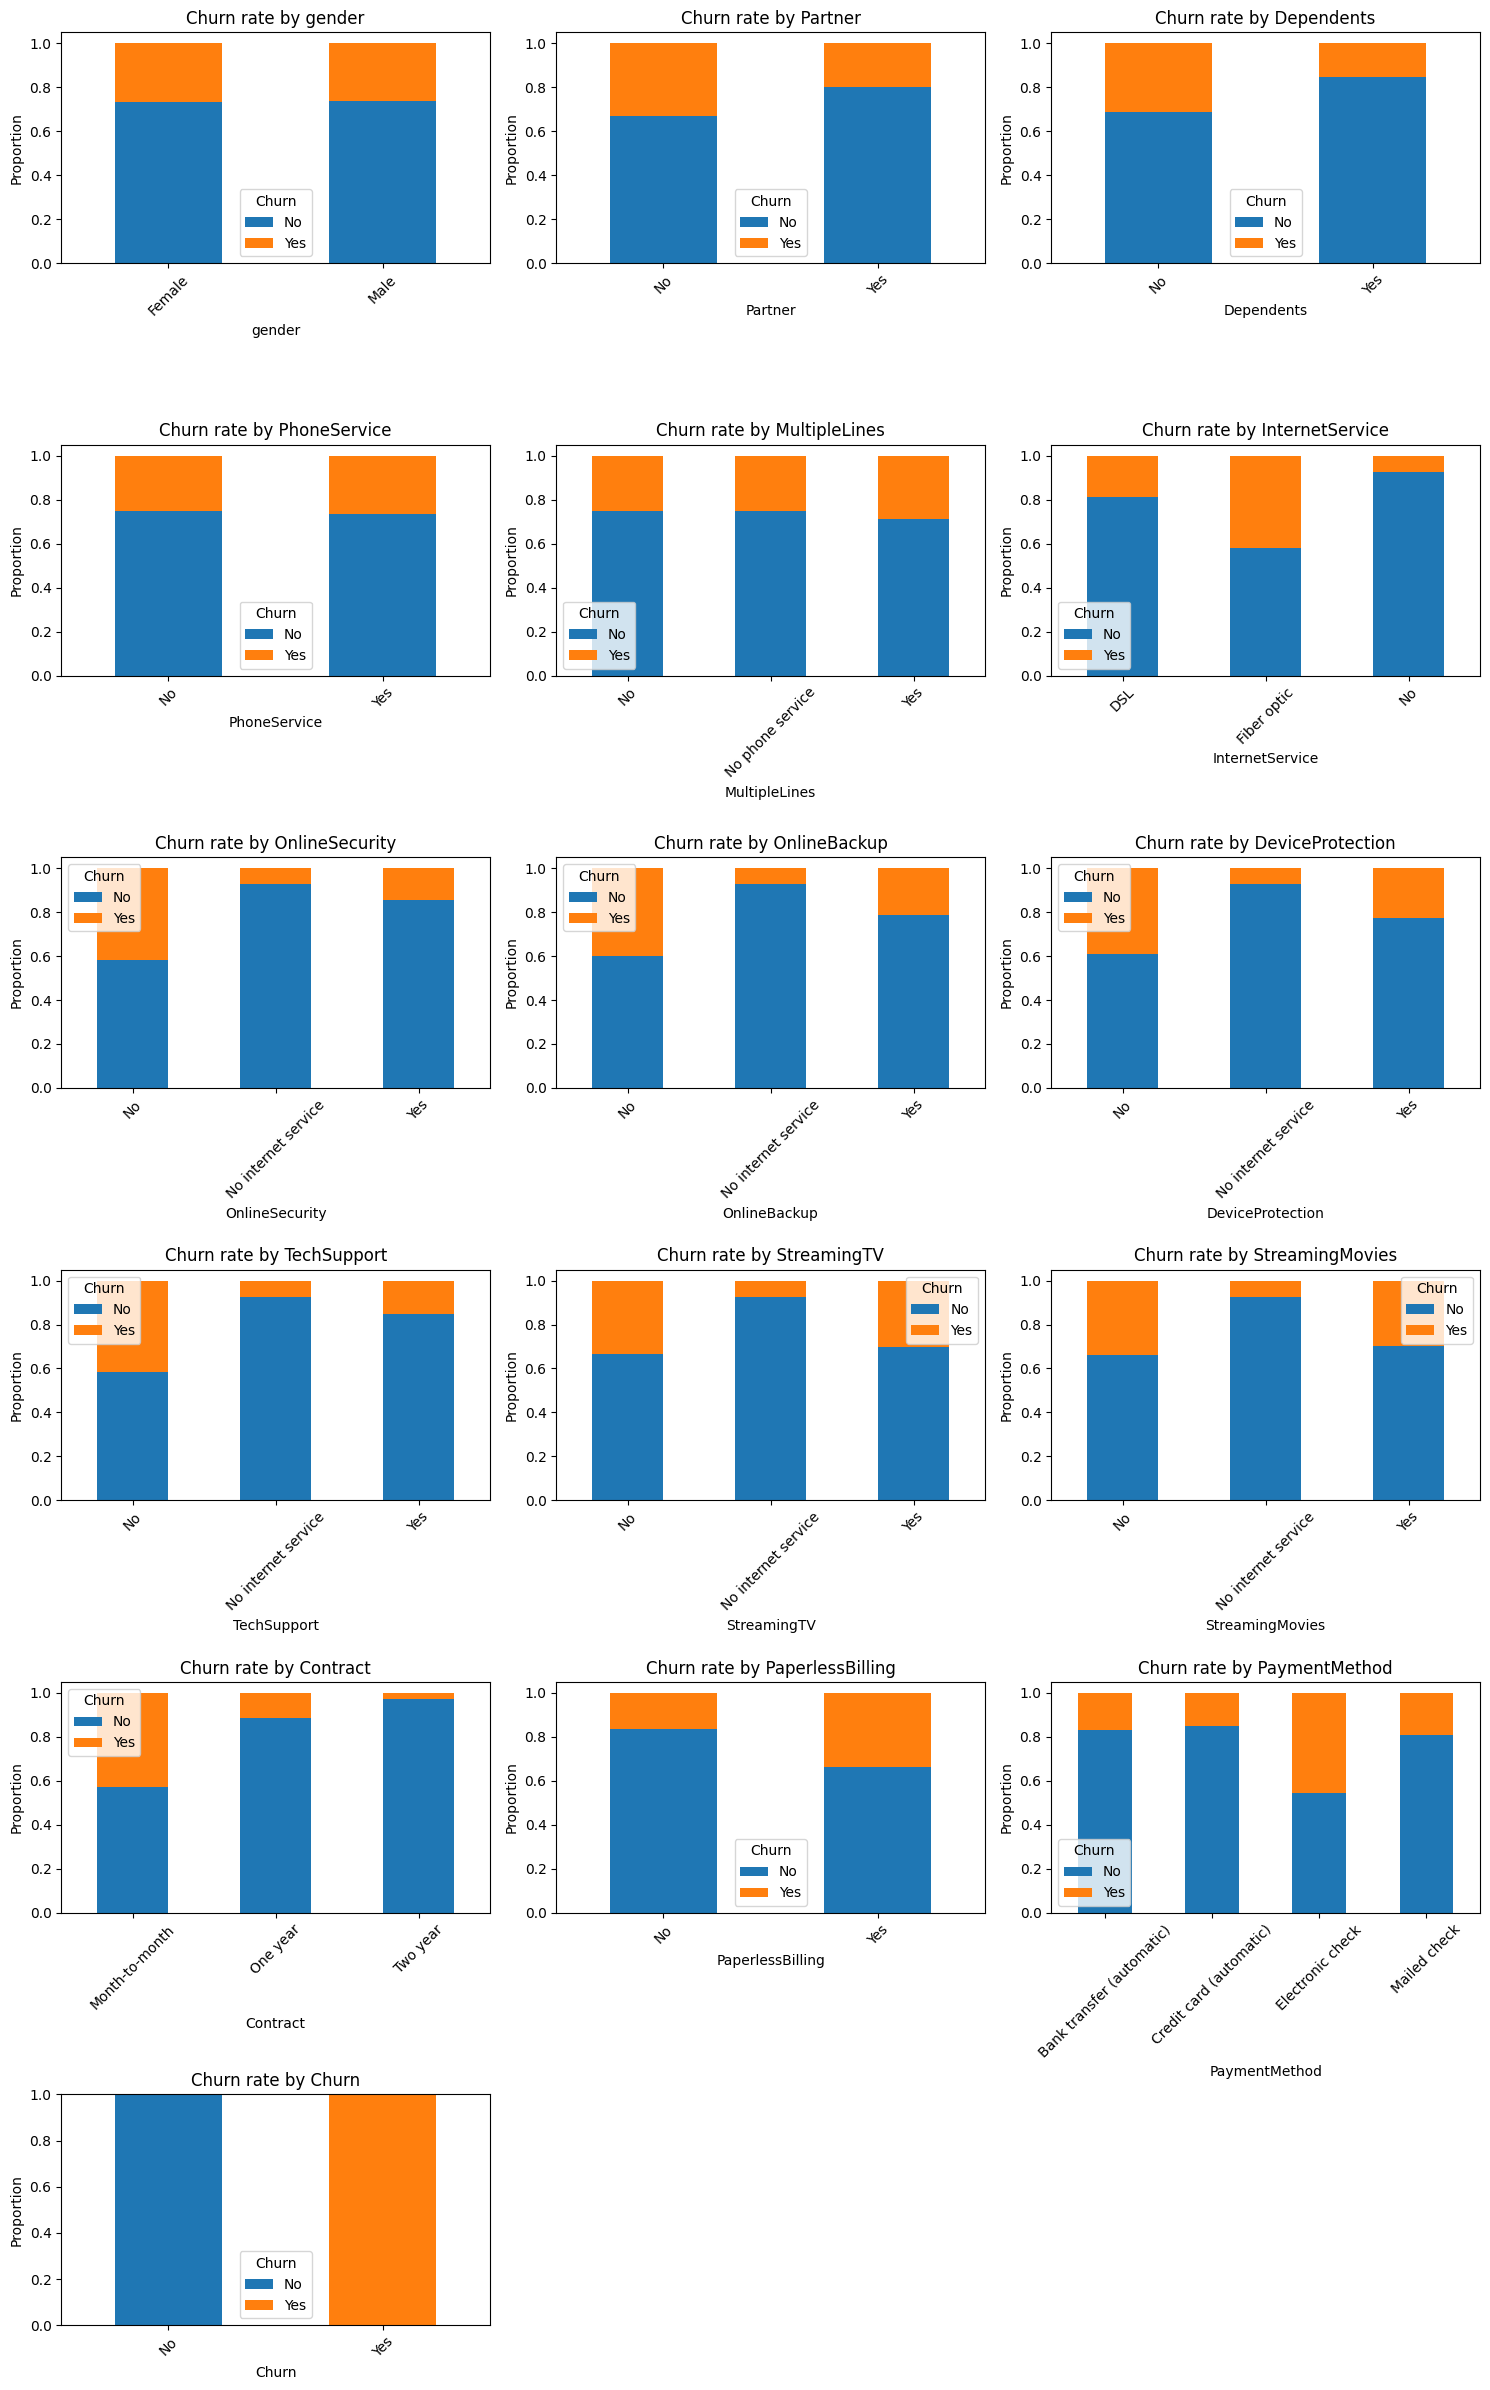

In [74]:
fig, axes = plt.subplots(6, 3, figsize=(15, 24))
fig.subplots_adjust(hspace=0.5)
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]

    ctab = pd.crosstab(df[col], df["Churn"], normalize="index")
    ctab.plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Churn")

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Key insights from categorical features

The categorical analysis suggests that churn is strongly associated with several service and contract-related factors:

- customers on month-to-month contracts are much more likely to churn than those on one-year or two-year contracts,
- fiber optic users appear to churn more often than DSL users,
- customers without online security or tech support show higher churn rates,
- electronic check users have noticeably higher churn,
- gender does not appear to have a meaningful relationship with churn.

### Numerical feature analysis

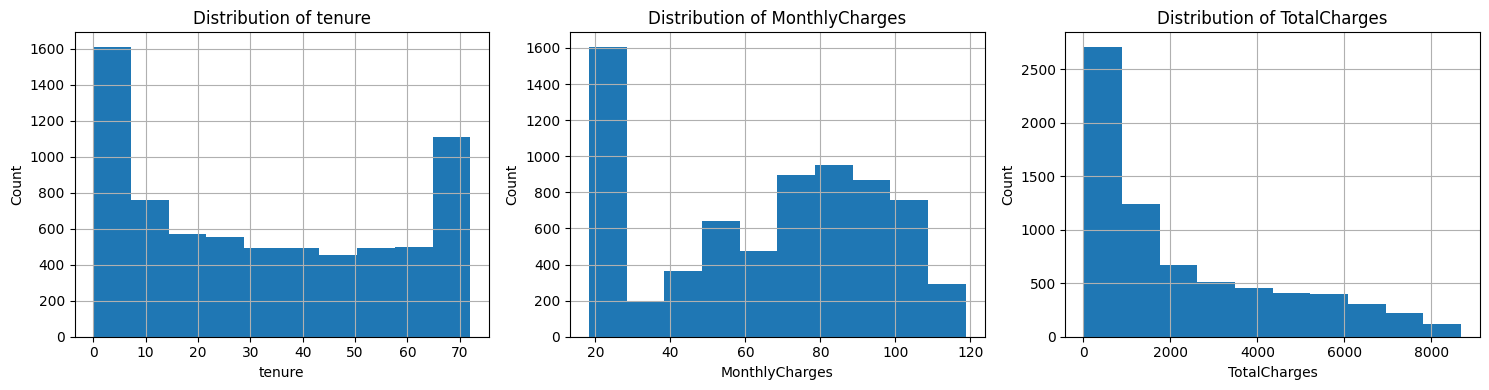

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    df[col].hist(ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

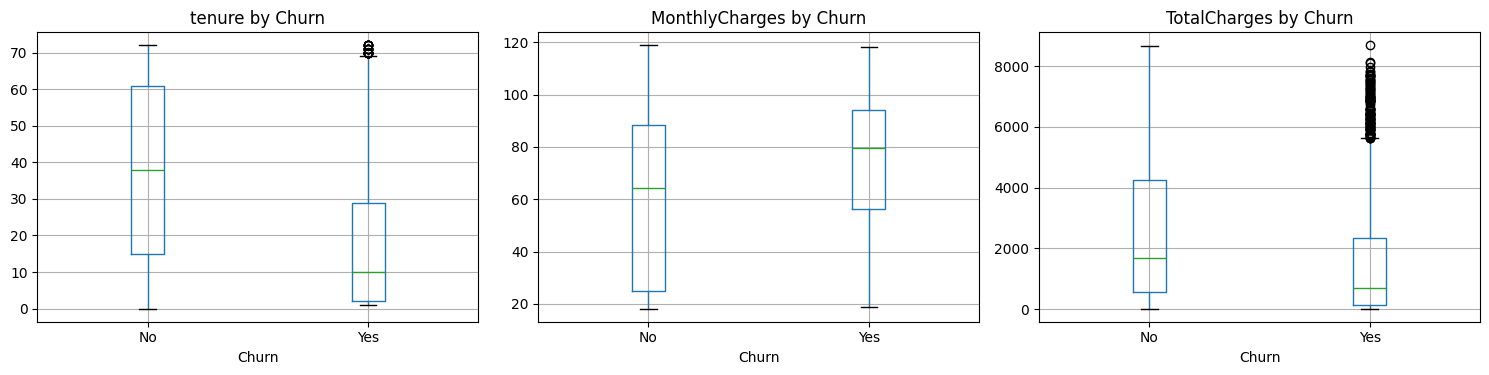

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    df.boxplot(column=col, by="Churn", ax=ax)
    ax.set_title(f"{col} by Churn")
    ax.set_xlabel("Churn")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [77]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2552.88
Yes,17.98,74.44,1531.80


### Key insights from numerical features

The numerical analysis shows clear differences between churned and retained customers:

- churned customers have much lower average tenure, which suggests that early-stage customers are more likely to leave,
- churned customers tend to have higher monthly charges,
- churned customers show lower total charges overall, likely because they stay for a shorter time.

These patterns are consistent with the business intuition that churn risk is highest among newer customers facing relatively expensive monthly plans.

### EDA key findings

Overall, the exploratory analysis suggests that churn is most strongly associated with:
- month-to-month contracts,
- shorter customer tenure,
- higher monthly charges,
- lack of online security and tech support,
- fiber optic internet service,
- electronic check as payment method.

## Modeling

In this section, I prepare the target variable, create a preprocessing pipeline, train multiple classification models, and compare their performance using classification metrics and ROC-AUC.

The goal is not only to find the best-performing model, but also to compare interpretability and business usefulness.

### Prepare target and train-test split

The target variable `Churn` is encoded into binary format:
- `No` → 0
- `Yes` → 1

Then the dataset is split into training and test sets using stratification to preserve the original class distribution.

In [79]:
df_model = df.copy()

df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

categorical_cols = X.select_dtypes(include=["str"]).columns
numerical_cols = X.select_dtypes(exclude=["str"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))

Train set shape: (5634, 19)
Test set shape: (1409, 19)

Target distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


### Preprocessing pipeline

To ensure a consistent modeling workflow, I use a shared preprocessing pipeline:

- numerical variables: median imputation + standard scaling,
- categorical variables: most frequent imputation + one-hot encoding.

This preprocessing is applied inside each model pipeline to prevent data leakage and keep the workflow reproducible.

In [80]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Define candidate models

To compare different modeling approaches, I selected:

- **Logistic Regression** – a simple and interpretable baseline,
- **Decision Tree** – a single-tree model that is easy to explain,
- **Random Forest** – an ensemble model that usually captures more complex patterns.

This comparison helps evaluate the trade-off between interpretability and predictive performance.

In [81]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

models

{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)}

### Train and evaluate models

Each model is trained using the same preprocessing pipeline and evaluated on the test set.

The following metrics are used:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Since the target classes are imbalanced, ROC-AUC, recall, and F1-score are more informative than accuracy alone.

In [82]:
fitted_pipelines = {}
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    fitted_pipelines[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841298
1,Decision Tree,0.798439,0.634731,0.566845,0.598870,0.829726
2,Random Forest,0.775018,0.597938,0.465241,0.523308,0.818704


According to the results in results_df, it can be observed that the model based on Logistic Regression achieved the highest ROC-AUC score, while also attaining the highest recall. The Decision Tree achieved the highest accuracy and precision. Based on the above results, for customer identification I would choose Logistic Regression, due to the fact that despite its lower accuracy, it had the highest ROC-AUC value.

In [83]:
results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.738,0.504,0.783,0.614,0.841
1,Decision Tree,0.798,0.635,0.567,0.599,0.830
2,Random Forest,0.775,0.598,0.465,0.523,0.819


### Detailed classification results

Below I review the classification report and confusion matrix for each model to better understand how well the models identify churned customers.

In [84]:
for model_name, pipeline in fitted_pipelines.items():
    y_pred = pipeline.predict(X_test)

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion matrix:
[[747 288]
 [ 81 293]]

Decision Tree

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion matrix:
[[913 122]
 [162 212]]

Random Forest

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.47

* Logistic Regression catches more churned customers but produces more false positives.
* Decision Tree is more balanced.
* Random Forest is more conservative and misses more churn cases.

### ROC curve comparison

To compare model performance visually, I plot ROC curves for all models on a single chart. This makes it easier to compare their ability to distinguish between churned and non-churned customers across classification thresholds.

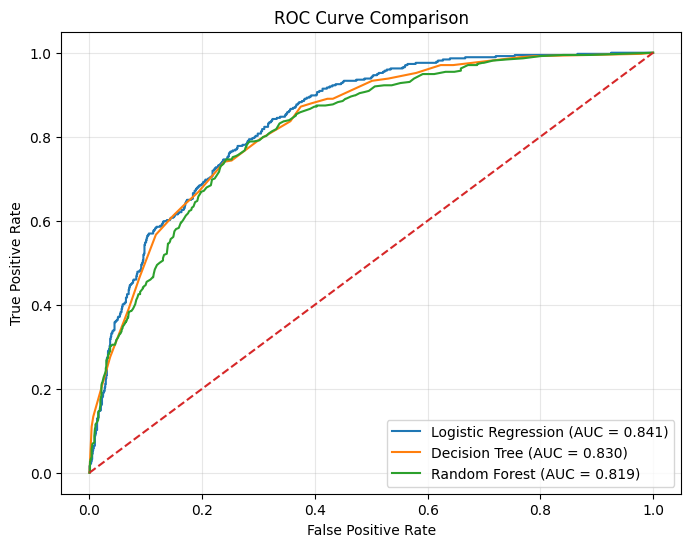

In [85]:
plt.figure(figsize=(8, 6))

for model_name, pipeline in fitted_pipelines.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Feature importance and interpretation

For interpretation, I use:
- model coefficients for Logistic Regression,
- feature importances for tree-based models.

This helps identify which features contribute most to churn prediction.

In [86]:
rf_pipeline = fitted_pipelines["Random Forest"]

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
3,num__TotalCharges,0.159641
1,num__tenure,0.140237
2,num__MonthlyCharges,0.138192
36,cat__Contract_Month-to-month,0.051151
18,cat__OnlineSecurity_No,0.033068
43,cat__PaymentMethod_Electronic check,0.030858
27,cat__TechSupport_No,0.028198
16,cat__InternetService_Fiber optic,0.026041
0,num__SeniorCitizen,0.019725
21,cat__OnlineBackup_No,0.018340


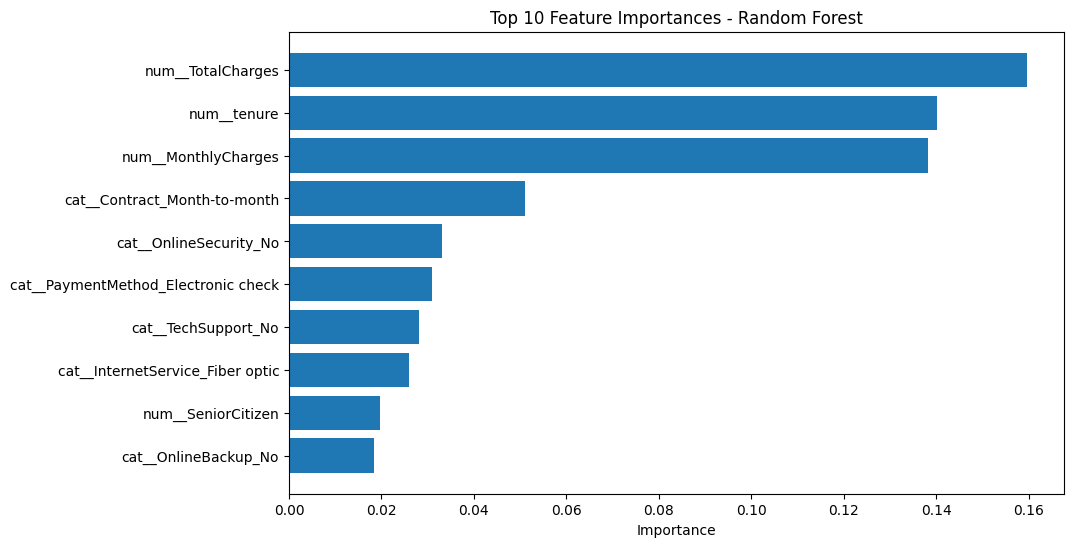

In [87]:
top_features = feature_importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

For the Random Forest model, the most important features turned out to be the numerical columns: TotalCharges, Tenure, and MonthlyCharges. Among the categorical variables, the most significant was the Contract column, particularly the "month-to-month" option. These observations are consistent with the EDA. Support-related services are also key.

In [88]:
logreg_pipeline = fitted_pipelines["Logistic Regression"]

logreg_feature_names = logreg_pipeline.named_steps["preprocessor"].get_feature_names_out()
logreg_coefficients = logreg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": logreg_feature_names,
    "Coefficient": logreg_coefficients
})

top_positive = coef_df.sort_values("Coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(10)

display(top_positive)
display(top_negative)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.705337
36,cat__Contract_Month-to-month,0.663399
3,num__TotalCharges,0.457218
35,cat__StreamingMovies_Yes,0.274978
32,cat__StreamingTV_Yes,0.262038
43,cat__PaymentMethod_Electronic check,0.238805
18,cat__OnlineSecurity_No,0.197856
27,cat__TechSupport_No,0.163785
14,cat__MultipleLines_Yes,0.132555
26,cat__DeviceProtection_Yes,0.074016


,Feature,Coefficient
1,num__tenure,-1.123595
38,cat__Contract_Two year,-0.781255
2,num__MonthlyCharges,-0.663583
15,cat__InternetService_DSL,-0.621009
25,cat__DeviceProtection_No internet service,-0.274569
22,cat__OnlineBackup_No internet service,-0.274569
19,cat__OnlineSecurity_No internet service,-0.274569
28,cat__TechSupport_No internet service,-0.274569
31,cat__StreamingTV_No internet service,-0.274569
17,cat__InternetService_No,-0.274569


### Interpretation of Logistic Regression coefficients

The coefficients of the Logistic Regression model indicate the direction of the relationship between each feature and the probability of customer churn.

Features with **positive coefficients** increase the likelihood of churn:
- `InternetService_Fiber optic`
- `Contract_Month-to-month`
- `PaymentMethod_Electronic check`
- `OnlineSecurity_No`
- `TechSupport_No`

This suggests that customers with flexible contracts, higher-risk service configurations, and lack of support services are more likely to leave.

Features with **negative coefficients** decrease the likelihood of churn:
- `tenure`
- `Contract_Two year`
- `InternetService_DSL`

This indicates that long-term customers and those with more stable contracts are less likely to churn.

It is important to note that Logistic Regression coefficients should be interpreted with caution, as some features may be correlated (e.g., tenure, total charges, and contract type). Therefore, individual coefficients may reflect combined effects of multiple related variables rather than purely independent impacts.

### Modeling summary

The models were trained using a shared preprocessing pipeline and evaluated on the same test set.

Main conclusions:
- the best model should be selected based on ROC-AUC together with recall and F1-score,
- Logistic Regression is the most interpretable model and makes it easier to explain churn drivers,
- Random Forest is more flexible and may capture more complex feature interactions,
- the final choice should balance predictive performance with interpretability.

From a business perspective, correctly identifying customers at risk of churn is usually more important than maximizing overall accuracy alone.

## Final conclusion

This project shows that customer churn is strongly related to contract type, tenure, monthly charges, and selected service features.

The modeling section confirms that churn prediction can be approached effectively with standard classification models combined with proper preprocessing. In practice, the final model choice should depend not only on performance metrics, but also on business needs such as interpretability and the cost of missing churn-risk customers.

### Final model choice

If I had to select a single model for practical use, I would choose **Logistic Regression**.

Although it does not achieve the highest accuracy, it provides:
- the highest ROC-AUC score,
- the highest recall,
- good interpretability.

In a churn prediction scenario, identifying as many at-risk customers as possible is often more important than maximizing overall accuracy. Logistic Regression performs best in this regard, as it detects a larger proportion of churned customers.

Additionally, its interpretability allows for clear explanation of churn drivers, which is valuable for business stakeholders and decision-making.

For these reasons, Logistic Regression offers the best balance between performance and usability in this project.

In a real-world scenario, further improvements could include hyperparameter tuning, threshold optimization, and cost-sensitive learning to better align the model with business objectives.